<h1><center>Migration Analysis</center></h1>

In [ ]:
# upload the needed modules.
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm
from scipy.stats import expon
from scipy.stats import ttest_ind
from scipy.stats import ttest_1samp
from scipy.stats import binom, poisson, geom, randint

import warnings



In [2]:
warnings.filterwarnings('ignore')

<h1><center>EDA</center></h1>

In [ ]:
# Import data.
new_pop_data = pd.read_csv('/Users/michaelperrine/Library/CloudStorage/OneDrive-Personal/my_portfolio_files/NST-EST2024-POPCHG2020-2024.csv')
new_pop_data.head()

,SUMLEV,REGION,DIVISION,STATE,NAME,ESTIMATESBASE2020,POPESTIMATE2020,POPESTIMATE2021,POPESTIMATE2022,POPESTIMATE2023,...,NRANK_NPCHG2020,NRANK_NPCHG2021,NRANK_NPCHG2022,NRANK_NPCHG2023,NRANK_NPCHG2024,NRANK_PPCHG2020,NRANK_PPCHG2021,NRANK_PPCHG2022,NRANK_PPCHG2023,NRANK_PPCHG2024
0,10,0,0,0,United States,331515736,331577720,332099760,334017321,336806231,...,X,X,X,X,X,X,X,X,X,X
1,20,1,0,0,Northeast Region,57617706,57431458,57252533,57159597,57398303,...,4,4,4,4,3,4,4,4,3,3
2,30,1,1,0,New England,15122011,15057350,15118145,15175633,15263573,...,8,4,5,9,9,9,4,5,5,4
3,30,1,2,0,Middle Atlantic,42495695,42374108,42134388,41983964,42134730,...,9,8,9,6,5,8,8,9,7,6
4,20,2,0,0,Midwest Region,68998970,68984258,68872831,68903297,69186401,...,3,3,3,3,4,3,3,3,4,4


In [ ]:
# View the first five rows.
new_pop_data.tail()

,c,REGION,DIVISION,STATE,NAME,ESTIMATESBASE2020,POPESTIMATE2020,POPESTIMATE2021,POPESTIMATE2022,POPESTIMATE2023,...,RINTERNATIONALMIG2023,RINTERNATIONALMIG2024,RDOMESTICMIG2021,RDOMESTICMIG2022,RDOMESTICMIG2023,RDOMESTICMIG2024,RNETMIG2021,RNETMIG2022,RNETMIG2023,RNETMIG2024
61,40,4,9,53,Washington,7707586,7727209,7743760,7794123,7857320,...,8.570200,10.316588,-2.028057,-0.444333,-2.209764,0.337770,-0.219379,5.160549,6.360436,10.654358
62,40,3,5,54,West Virginia,1793736,1791646,1785618,1774122,1770495,...,1.309027,1.604870,1.668314,0.162371,1.859721,2.553330,2.074770,1.102328,3.168749,4.158200
63,40,2,3,55,Wisconsin,5894170,5897375,5881608,5903975,5930405,...,3.083727,3.724715,-3.158677,1.273081,1.298758,1.064973,-2.617204,4.614960,4.382486,4.789688
64,40,4,8,56,Wyoming,576844,577681,579636,581978,585067,...,1.777138,2.191552,3.126196,4.216547,2.983604,1.468425,3.362951,5.165227,4.760742,3.659977
65,40,X,X,72,Puerto Rico,3285874,3281590,3262711,3220137,3203792,...,-0.016812,4.745995,0.000000,0.000000,0.000000,0.000000,-1.319316,-8.681678,-0.016812,4.745995


In [ ]:
# Create a subset of the data.
pop_sub = new_pop_data[["NAME", "POPESTIMATE2023", "RINTERNATIONALMIG2023","RDOMESTICMIG2023","RNETMIG2023", "RINTERNATIONALMIG2024", "RDOMESTICMIG2024", "RNETMIG2024",  ]]

In [ ]:
# View first five rows of subset.
pop_sub.head()

,NAME,POPESTIMATE2023,RINTERNATIONALMIG2023,RDOMESTICMIG2023,RNETMIG2023,RINTERNATIONALMIG2024,RDOMESTICMIG2024,RNETMIG2024
0,United States,336806231,6.840246,0.000000,6.840246,8.231786,0.000000,8.231786
1,Northeast Region,57398303,8.175150,-4.857718,3.317432,9.848371,-3.334322,6.514050
2,New England,15263573,8.005202,-2.067991,5.937211,9.622685,-1.575091,8.047594
3,Middle Atlantic,42134730,8.236647,-5.867209,2.369438,9.930153,-3.971810,5.958342
4,Midwest Region,69186401,4.859117,-1.300416,3.558701,5.861482,-0.709222,5.152260


In [ ]:
# Rename columns.
pop_sub.rename(columns={'POPESTIMATE2023':'popestimate2023', 'RINTERNATIONALMIG2023':'internationalmig2023', 'RDOMESTICMIG2023':'domesticmig2023', 'RNETMIG2023':'netmig2023','RINTERNATIONALMIG2024':'internationalmig2024', 'RDOMESTICMIG2024':'domesticmig2024', 'RNETMIG2024':'netmig2024'}, inplace=True)
pop_sub.head()

,NAME,popestimate2023,internationalmig2023,domesticmig2023,netmig2023,internationalmig2024,domesticmig2024,netmig2024
0,United States,336806231,6.840246,0.000000,6.840246,8.231786,0.000000,8.231786
1,Northeast Region,57398303,8.175150,-4.857718,3.317432,9.848371,-3.334322,6.514050
2,New England,15263573,8.005202,-2.067991,5.937211,9.622685,-1.575091,8.047594
3,Middle Atlantic,42134730,8.236647,-5.867209,2.369438,9.930153,-3.971810,5.958342
4,Midwest Region,69186401,4.859117,-1.300416,3.558701,5.861482,-0.709222,5.152260


The following codes displays histograms of population estimate for 2023, international estimate for 2023, domestic migration for 2023, net migration for 2023, international estimate for 2024, domestic migration for 2024, and net migration for 2024  

Text(0, 0.5, 'Totals')

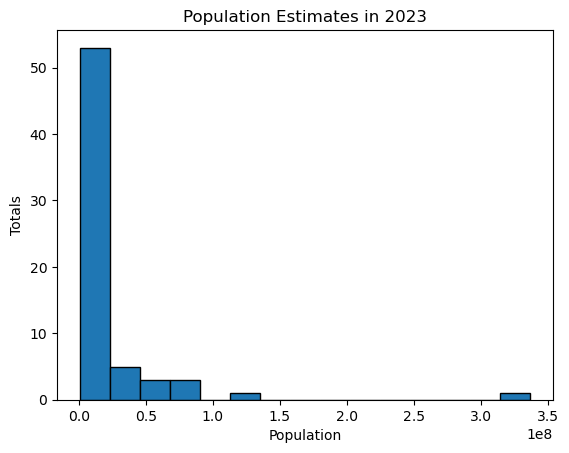

In [ ]:
pop_sub.hist("popestimate2023", bins =15, edgecolor = "black", grid=False)
plt.title("Population Estimates in 2023")
plt.xlabel("Population")
plt.ylabel("Totals")



Text(0, 0.5, 'Totals')

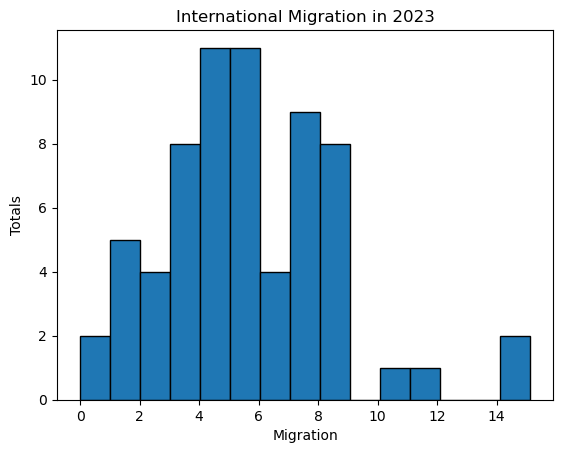

In [ ]:
pop_sub.hist("internationalmig2023", bins=15, edgecolor = "black", grid=False)
plt.title("International Migration in 2023")
plt.xlabel("Migration")
plt.ylabel("Totals")

Text(0, 0.5, 'Totals')

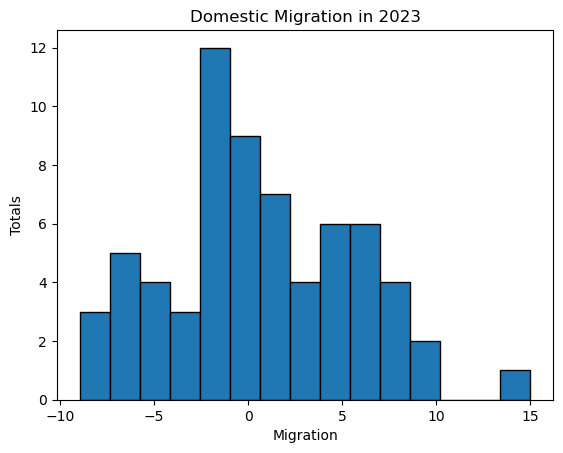

In [ ]:
pop_sub.hist("domesticmig2023", bins=15, edgecolor = "black", grid=False)
plt.title("Domestic Migration in 2023")
plt.xlabel("Migration")
plt.ylabel("Totals")

Text(0, 0.5, 'Totals')

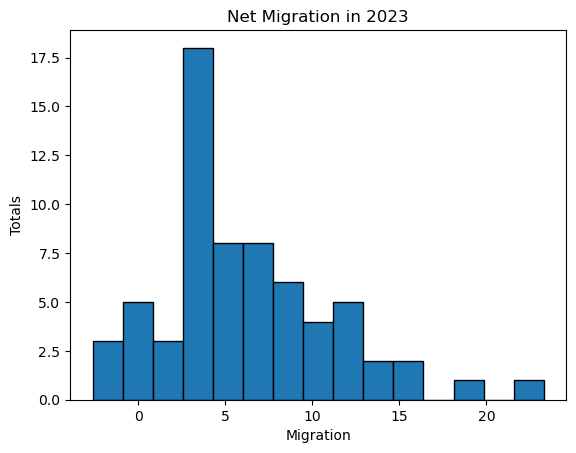

In [ ]:
pop_sub.hist("netmig2023", bins=15, edgecolor = "black", grid=False)
plt.title("Net Migration in 2023")
plt.xlabel("Migration")
plt.ylabel("Totals")


Text(0, 0.5, 'Totals')

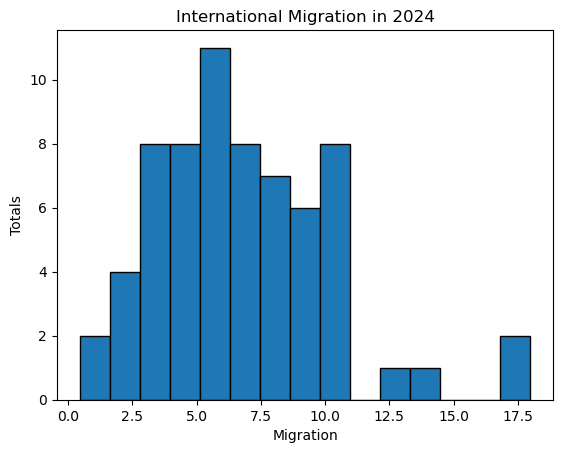

In [ ]:
pop_sub.hist("internationalmig2024", bins=15, edgecolor = "black", grid=False)
plt.title("International Migration in 2024")
plt.xlabel("Migration")
plt.ylabel("Totals")

Text(0, 0.5, 'Totals')

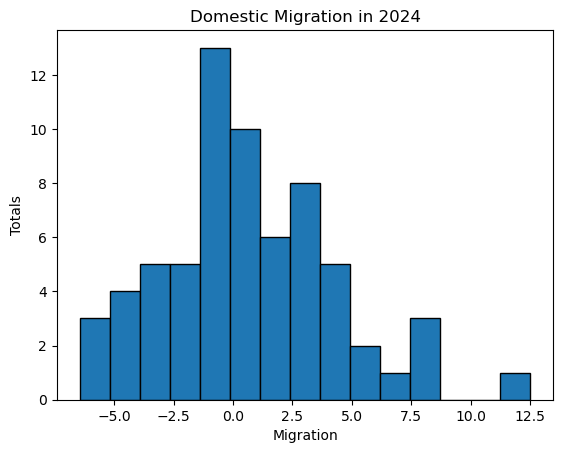

In [ ]:
pop_sub.hist("domesticmig2024", bins=15, edgecolor = "black", grid=False)
plt.title("Domestic Migration in 2024")
plt.xlabel("Migration")
plt.ylabel("Totals")

Text(0, 0.5, 'Totals')

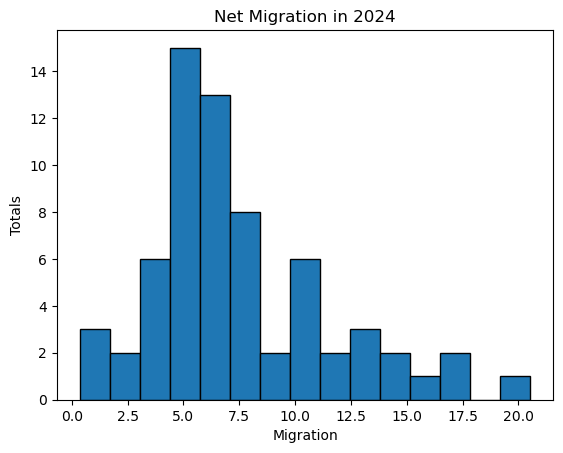

In [ ]:
pop_sub.hist("netmig2024", bins=15, edgecolor = "black", grid=False)
plt.title("Net Migration in 2024")
plt.xlabel("Migration")
plt.ylabel("Totals")


In [ ]:
# View summary statistics of the data.
pop_sub.describe()

,popestimate2023,internationalmig2023,domesticmig2023,netmig2023,internationalmig2024,domesticmig2024,netmig2024
count,6.600000e+01,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000
mean,2.046104e+07,5.604665,0.632548,6.237214,6.811009,0.681475,7.492484
std,4.600011e+07,2.973309,5.054493,4.957009,3.445100,3.702904,4.112687
min,5.850670e+05,-0.016812,-8.969980,-2.610829,0.446103,-6.456030,0.345378
25%,2.945254e+06,3.472095,-2.023871,3.335611,4.324618,-1.474819,4.979594
50%,6.069222e+06,5.281272,0.000000,5.140924,6.328952,0.149280,6.311731
75%,1.861892e+07,7.327038,4.754527,8.501991,8.853701,3.030828,9.767059
max,3.368062e+08,15.131421,15.004452,23.287515,17.994004,12.523258,20.543170


In [ ]:
# Drop name column.
pop_sub.drop([ "NAME"], axis= 1).mode()

,popestimate2023,internationalmig2023,domesticmig2023,netmig2023,internationalmig2024,domesticmig2024,netmig2024
0,585067,-0.016812,0.0,-2.610829,0.446103,0.0,0.345378
1,648708,0.329281,NaN,-2.032697,1.604870,NaN,0.628587
2,687324,1.309027,NaN,-1.309862,1.753687,NaN,1.249100
3,736510,1.437615,NaN,-0.825888,1.998111,NaN,1.781452
4,789047,1.623627,NaN,-0.326715,2.191552,NaN,2.332715
...,...,...,...,...,...,...,...
61,68684308,8.643265,NaN,14.525762,10.461458,NaN,14.784949
62,69186401,10.591214,NaN,14.911299,12.704169,NaN,15.383927
63,79328169,11.560242,NaN,15.474602,13.844130,NaN,16.799457
64,130893358,15.113932,NaN,18.606067,17.776488,NaN,17.508963


The following code created the pmf distribution 

In [ ]:
from scipy.stats import binom, poisson,geom,randint

In [ ]:
pop_tot =pop_sub["netmig2023"].min()
print(pop_tot)

-2.610828994


In [ ]:
pop_tot_1 =pop_sub["netmig2023"].max()
print(pop_tot_1)

23.28751454


In [ ]:
k = np.arange(-3,23)
p = poisson.pmf(k,10)
p

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 4.53999298e-05,
       4.53999298e-04, 2.26999649e-03, 7.56665496e-03, 1.89166374e-02,
       3.78332748e-02, 6.30554580e-02, 9.00792257e-02, 1.12599032e-01,
       1.25110036e-01, 1.25110036e-01, 1.13736396e-01, 9.47803301e-02,
       7.29079462e-02, 5.20771044e-02, 3.47180696e-02, 2.16987935e-02,
       1.27639962e-02, 7.09110899e-03, 3.73216263e-03, 1.86608131e-03,
       8.88610150e-04, 4.03913704e-04])

<function matplotlib.pyplot.show(close=None, block=None)>

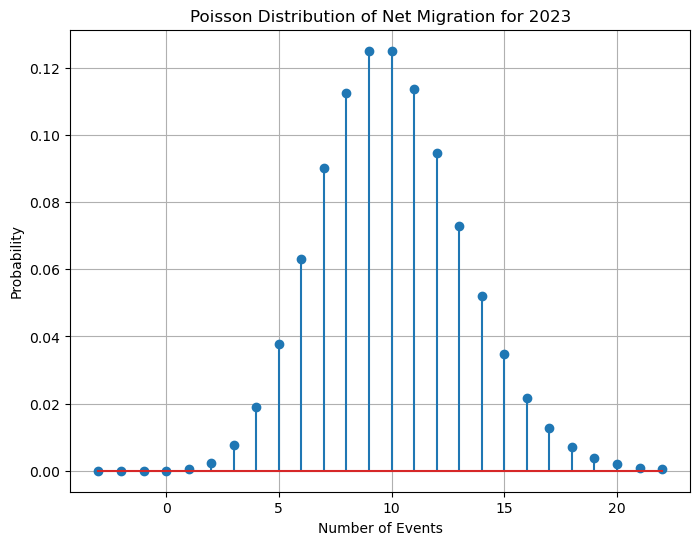

In [ ]:
plt.figure(figsize= (8,6))
plt.stem(k, p)
plt.xlabel("Number of Events")
plt.ylabel("Probability")
plt.title("Poisson Distribution of Net Migration for 2023")
plt.grid(True)
plt.show

The following code creates my CDF for domestic migration. First I created a new variable for domestic migration. Next I created the code to calculate the values and appended them to the cdf values list.

In [ ]:
data = pop_sub["domesticmig2023"]

data_len= len(data)
cdf_values=[]
for i in range(data_len):
    cdf_value = np.sum(data <= data[i])/data_len
    cdf_values.append(cdf_value)


print(cdf_values)


[np.float64(0.5151515151515151), np.float64(0.18181818181818182), np.float64(0.25757575757575757), np.float64(0.12121212121212122), np.float64(0.36363636363636365), np.float64(0.2727272727272727), np.float64(0.48484848484848486), np.float64(0.803030303030303), np.float64(0.8333333333333334), np.float64(0.7727272727272727), np.float64(0.7575757575757576), np.float64(0.19696969696969696), np.float64(0.6818181818181818), np.float64(0.06060606060606061), np.float64(0.8636363636363636), np.float64(0.09090909090909091), np.float64(0.7272727272727273), np.float64(0.8484848484848485), np.float64(0.030303030303030304), np.float64(0.5606060606060606), np.float64(0.3181818181818182), np.float64(0.9848484848484849), np.float64(0.21212121212121213), np.float64(0.9393939393939394), np.float64(0.7424242424242424), np.float64(0.045454545454545456), np.float64(0.9090909090909091), np.float64(0.10606060606060606), np.float64(0.5454545454545454), np.float64(0.3939393939393939), np.float64(0.3030303030303

This code creates the graph showing the cdf

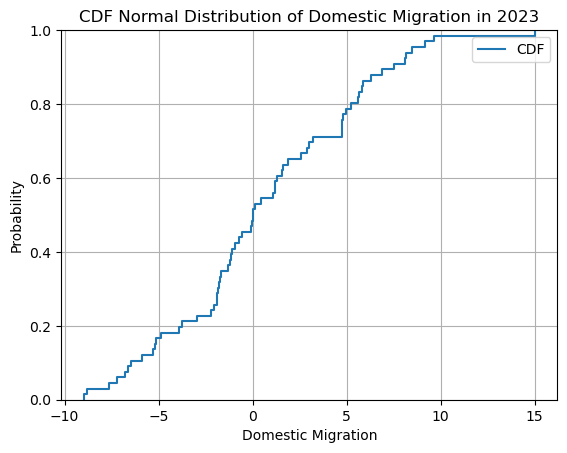

In [ ]:
sns.ecdfplot(data, label="CDF")
plt.title("CDF Normal Distribution of Domestic Migration in 2023")
plt.xlabel("Domestic Migration")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
data_1 = pop_sub["netmig2023"]

data_1_len= len(data_1)
cdf_values=[]
for i in range(data_1_len):
    cdf_value = np.sum(data_1 <= data_1[i])/data_1_len
    cdf_values.append(cdf_value)


print(cdf_values)

[np.float64(0.6515151515151515), np.float64(0.25757575757575757), np.float64(0.5606060606060606), np.float64(0.16666666666666666), np.float64(0.2878787878787879), np.float64(0.22727272727272727), np.float64(0.4090909090909091), np.float64(0.9090909090909091), np.float64(0.9242424242424242), np.float64(0.7121212121212122), np.float64(0.8787878787878788), np.float64(0.19696969696969696), np.float64(0.7727272727272727), np.float64(0.10606060606060606), np.float64(0.7424242424242424), np.float64(0.030303030303030304), np.float64(0.8939393939393939), np.float64(0.6818181818181818), np.float64(0.045454545454545456), np.float64(0.5454545454545454), np.float64(0.6212121212121212), np.float64(0.9696969696969697), np.float64(0.8484848484848485), np.float64(1.0), np.float64(0.7878787878787878), np.float64(0.06060606060606061), np.float64(0.8181818181818182), np.float64(0.13636363636363635), np.float64(0.3939393939393939), np.float64(0.3484848484848485), np.float64(0.2727272727272727), np.float64(

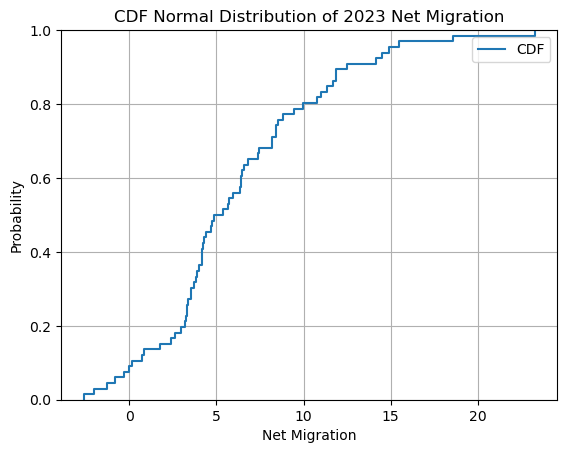

In [ ]:
sns.ecdfplot(data_1, label="CDF")
plt.title("CDF Normal Distribution of 2023 Net Migration")
plt.xlabel("Net Migration")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)
plt.show()

The following code created the scatter plots for the analysis

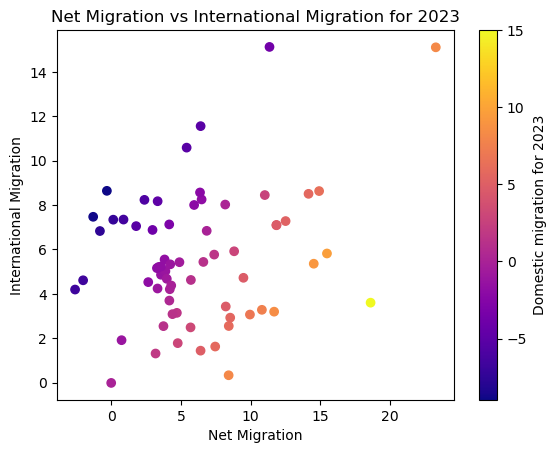

In [ ]:


plt.scatter(x = "netmig2023", y = "internationalmig2023", data = pop_sub, c="domesticmig2023", cmap="plasma")
plt.rcParams["figure.figsize"] = (10,8)
plt.title("Net Migration vs International Migration for 2023")
plt.xlabel("Net Migration")
plt.ylabel("International Migration")
plt.colorbar(label = "Domestic migration for 2023")
plt.show()

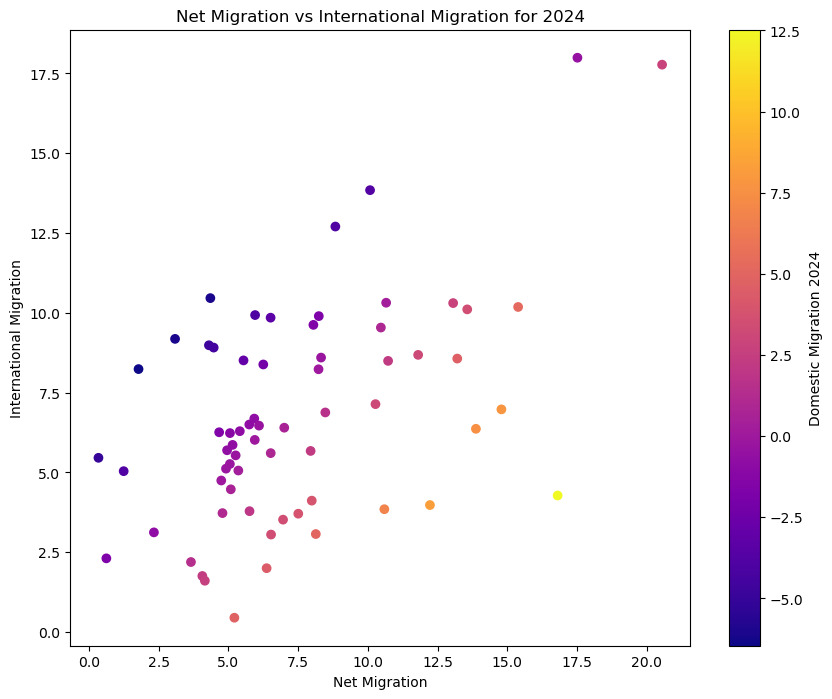

In [ ]:
plt.scatter(x = "netmig2024", y = "internationalmig2024", data = pop_sub, c="domesticmig2024", cmap="plasma")
plt.rcParams["figure.figsize"] = (10,8)
plt.title("Net Migration vs International Migration for 2024")
plt.xlabel("Net Migration")
plt.ylabel("International Migration")
plt.colorbar(label= "Domestic Migration 2024")
plt.show()

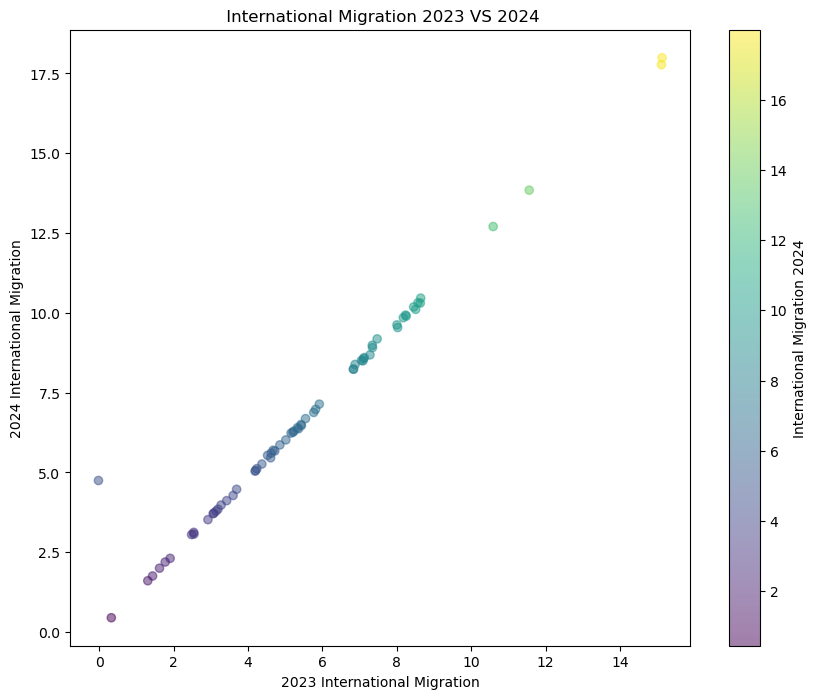

In [ ]:
plt.scatter(x = "internationalmig2023", y = "internationalmig2024", data = pop_sub, c="internationalmig2024",
            alpha=0.5)
plt.rcParams["figure.figsize"] = (8,8)
plt.title(" International Migration 2023 VS 2024")
plt.xlabel("2023 International Migration")
plt.ylabel("2024 International Migration")
plt.colorbar(label="International Migration 2024")
plt.show()

The following code creates the linear regression analysis

In [ ]:
ttest, pvalue =ttest_ind(pop_sub["internationalmig2023"], pop_sub["domesticmig2023"])
pvalue

np.float64(2.1813859463207968e-10)

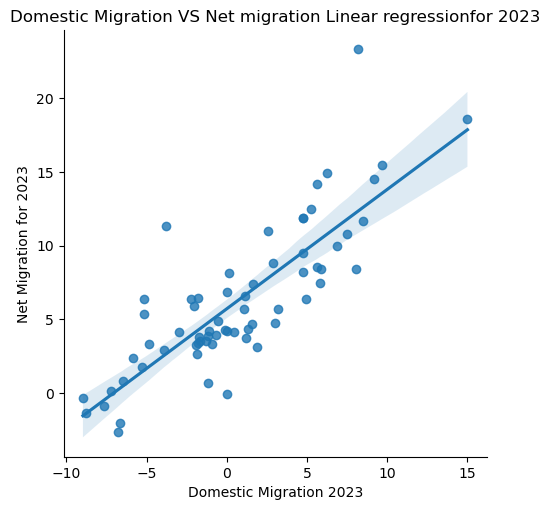

In [ ]:
sns.lmplot(x = "domesticmig2023", y ="netmig2023" , data = pop_sub)
plt.title("Domestic Migration VS Net migration Linear regressionfor 2023")
plt.xlabel("Domestic Migration 2023")
plt.ylabel("Net Migration for 2023")
plt.show()

In [ ]:
pop_sub_1= pop_sub.drop("NAME", axis = 1)

pop_sub_1.head()

,popestimate2023,internationalmig2023,domesticmig2023,netmig2023,internationalmig2024,domesticmig2024,netmig2024
0,336806231,6.840246,0.000000,6.840246,8.231786,0.000000,8.231786
1,57398303,8.175150,-4.857718,3.317432,9.848371,-3.334322,6.514050
2,15263573,8.005202,-2.067991,5.937211,9.622685,-1.575091,8.047594
3,42134730,8.236647,-5.867209,2.369438,9.930153,-3.971810,5.958342
4,69186401,4.859117,-1.300416,3.558701,5.861482,-0.709222,5.152260


In [ ]:
pop_sub_1.columns

Index(['popestimate2023', 'internationalmig2023', 'domesticmig2023',
       'netmig2023', 'internationalmig2024', 'domesticmig2024', 'netmig2024'],
      dtype='object')

In [ ]:
X = pop_sub_1[['netmig2023','internationalmig2023', 'domesticmig2023']]


In [ ]:
y = pop_sub_1['popestimate2023']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2)

In [ ]:
model = LinearRegression()


In [ ]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
model.score(X_test, y_test)

-1.4153261003139312

In [ ]:
model.score(X_train, y_train)

0.08757911130817098

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
mean_absolute_error(y_test, y_pred)

23532951.449303098

In [ ]:
mean_squared_error(y_test, y_pred)

965275671814448.2

In [ ]:
r2_score(y_test, y_pred)

-1.4153261003139312

In [ ]:
model.coef_

array([-5.06791413e+15,  5.06791414e+15,  5.06791413e+15])

In [ ]:
model.intercept_

np.float64(-7481529.940370351)